Nama : Muhammad Khasan Zubaeri

NIM : 250401020089

Kelas : IF403

Shape: (300, 4)

Statistik Deskriptif:
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


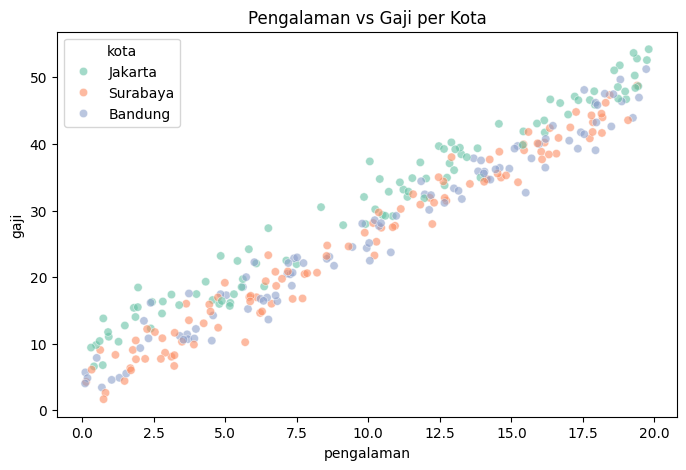

In [ ]:
# --------------------------------------------------
# LANGKAH 1 - Generate & Eksplorasi Dataset
# --------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate dataset sintetis
np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n)  # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta', 'Surabaya', 'Bandung'], n)

gaji = (
    3.0
    + 2.2 * pengalaman
    + 1.5 * edu
    + np.where(kota == 'Jakarta', 4.0, 0)
    + np.random.normal(0, 2, n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

# EDA singkat
print('Shape:', df.shape)
print('\nStatistik Deskriptif:')
print(df.describe().round(2))

# Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette='Set2',
    alpha=0.6
)
plt.title('Pengalaman vs Gaji per Kota')
plt.show()

In [ ]:
# --------------------------------------------------
# LANGKAH 2 - Preprocessing
# --------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-Hot Encoding kolom 'kota'
df = pd.get_dummies(df, columns=['kota'],
                    drop_first=True, dtype=int)

print('Kolom setelah encoding:', df.columns.tolist())

# Pisahkan fitur dan target
X = df.drop('gaji', axis=1)
y = df['gaji']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f'Train: {X_train.shape[0]} baris, Test: {X_test.shape[0]} baris')

# StandardScaler — fit pada training set saja
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Kolom setelah encoding: ['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']
Train: 240 baris, Test: 60 baris


In [ ]:
# --------------------------------------------------
# LANGKAH 3 - Latih Model & Tampilkan Koefisien
# --------------------------------------------------
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_s, y_train)

# Tampilkan koefisien
print(f'β₀ (intercept): {model.intercept_:.3f}')
print()

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values('Koefisien', ascending=False)

print(coef_df.to_string(index=False))

β₀ (intercept): 27.514

        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [ ]:
# --------------------------------------------------
# LANGKAH 4 - Evaluasi Model
# --------------------------------------------------
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('=== Metrik Evaluasi ===')
print(f'MAE = {mae:.3f} juta rupiah')
print(f'RMSE = {rmse:.3f} juta rupiah')
print(f'R² = {r2:.4f} ({r2*100:.1f}% variasi dijelaskan)')
print(f'Selisih RMSE-MAE = {rmse-mae:.3f}')

=== Metrik Evaluasi ===
MAE = 1.649 juta rupiah
RMSE = 2.123 juta rupiah
R² = 0.9740 (97.4% variasi dijelaskan)
Selisih RMSE-MAE = 0.474


maka interpretarisnya :
Model memiliki rata-rata kesalahan prediksi sebesar 1,649 juta rupiah. Nilai RMSE sebesar 2,123 juta rupiah sedikit lebih tinggi daripada MAE, menunjukkan adanya beberapa kesalahan prediksi yang lebih besar, tetapi tidak terlalu ekstrem. Nilai R² sebesar 0,9740 menunjukkan bahwa model mampu menjelaskan 97,4% variasi gaji, sehingga performa model tergolong sangat baik. Selisih RMSE dan MAE yang relatif kecil mengindikasikan tidak terdapat outlier yang signifikan pada data uji.

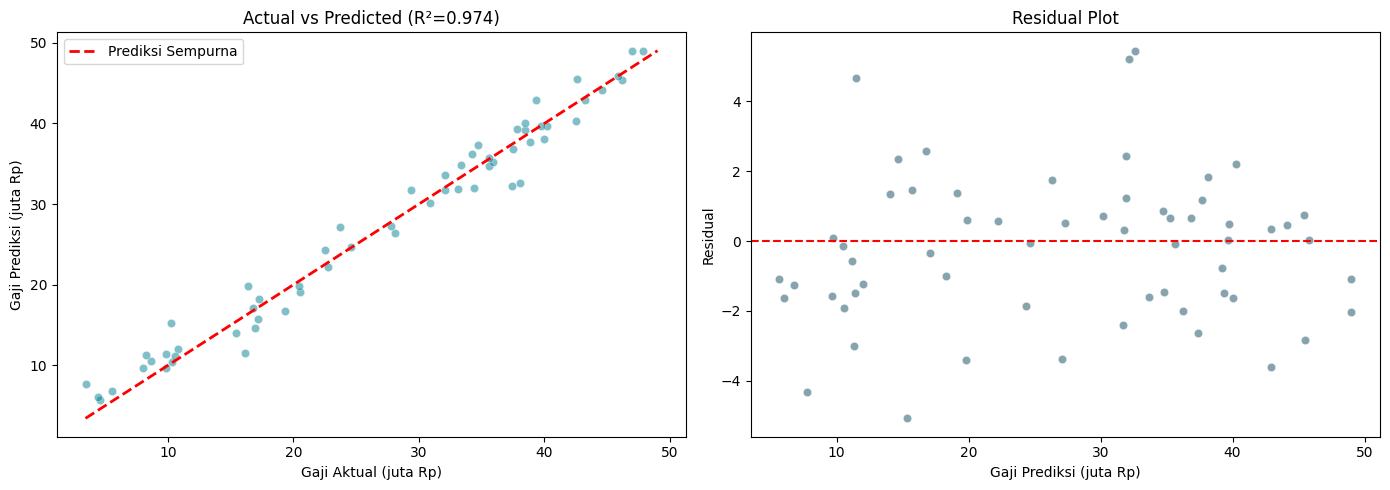

In [ ]:
# --------------------------------------------------
# LANGKAH 5 - Visualisasi & Interpretasi
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(
    y_test, y_pred,
    alpha=0.5,
    color='#028090',
    edgecolors='white',
    lw=0.5
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims, lims,
    'r--',
    lw=2,
    label='Prediksi Sempurna'
)

axes[0].set_xlabel('Gaji Aktual (juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (juta Rp)')
axes[0].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[0].legend()

# Plot 2: Residual Plot
residual = y_test - y_pred

axes[1].scatter(
    y_pred,
    residual,
    alpha=0.5,
    color='#114B5F',
    edgecolors='white',
    lw=0.5
)

axes[1].axhline(
    y=0,
    color='red',
    linestyle='--'
)

axes[1].set_xlabel('Gaji Prediksi (juta Rp)')
axes[1].set_ylabel('Residual')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

Interpretasi dengan What - So What - Now What

1.**Actual vs Predicted**

**What** : Grafik membandingkan nilai gaji aktual dengan nilai gaji hasil prediksi model.

**So What** : Jika titik-titik berada dekat garis diagonal merah, maka prediksi model mendekati nilai aktual. Semakin rapat terhadap garis tersebut, semakin baik performa model.

**Now What** : Jika masih banyak titik jauh dari garis diagonal, model dapat ditingkatkan dengan menambah fitur atau mencoba algoritma regresi lain.

**2.Residual Plot**

**What** : Grafik menampilkan residual (selisih antara nilai aktual dan prediksi) terhadap nilai prediksi.

**So What** : Jika residual tersebar acak di sekitar garis nol tanpa pola tertentu, asumsi regresi linear cukup terpenuhi dan model bekerja dengan baik.

**Now What** : Jika terlihat pola tertentu (misalnya membentuk kurva atau corong), model linear mungkin belum mampu menangkap hubungan data secara optimal sehingga perlu dilakukan perbaikan model atau transformasi fitur.

**Kesimpulan terhadap kegiatan praktikum:**

> Praktikum mempelajari mengenai cara membangun model Regresi Linear untuk memprediksi gaji berdasarkan beberapa faktor, yaitu pengalaman kerja, tingkat pendidikan, dan kota tempat bekerja. Selain itu juga mempelajari tahapan Machine Learning mulai dari eksplorasi data, preprocessing, pelatihan model, evaluasi menggunakan metrik MAE, RMSE, dan R², serta visualisasi dan menginterpretasikan hasil prediksi dengan What - So What - Now What.

> Temuan utama dari hasil praktikum bahwa model regresi linear mampu menangkap pola hubungan yang cukup baik serta menghasilkan prediksi yang mendekati nilai aktual.

> Keterbatasan : dataset yang digunakan merupakan data gaji sintetis sehingga apakah model regresi linear masih memberikan hasil yang baik jika menggunakan data gaji nyata.





